In [14]:
import numpy as np
import umap
import matplotlib.pyplot as plt

In [15]:
synt_path = "/home/zagorulia/ml/train/embeddings_for_umap/source_embeddings.npy"
real_path = "/home/zagorulia/ml/train/embeddings_for_umap/target_embeddings.npy"
test_path = "/home/zagorulia/ml/train/embeddings_for_umap/test_embeddings.npy"
test_lables_path = "/home/zagorulia/ml/train/embeddings_for_umap/test_labels.npy"

synt_path_da = "../scripts/model.ptcnn_DA_20260401-230242/latent_vectors/latent_vecs_CNN_0805_source_best_model_val_acc.npy"
real_path_da = "../scripts/model.ptcnn_DA_20260401-230242/latent_vectors/latent_vecs_CNN_domain_0305_best_model_val_acc.npy"
test_path_da = "../scripts/model.ptcnn_DA_20260401-230242/latent_vectors/latent_vecs_CNN_test_conf_mat_best_model_val_acc.npy"

# synt_labels_path_da = "../scripts/model.ptcnn_DA_20260401-230242/y_true/y_true_CNN_0805_source_best_model_val_acc.npy"
test_lables_path_da = "../scripts/model.ptcnn_DA_20260401-230242/y_true/y_true_CNN_test_conf_mat_best_model_val_acc.npy"

In [16]:
def load_latents(path: str) -> np.ndarray:
    X = np.load(path, allow_pickle=True)
    print(path, type(X), X.shape)
    return X

def get_umaps(synt_path, real_path, test_path):
    synt_latent = load_latents(synt_path)
    real_latent = load_latents(real_path)
    test_latent = load_latents(test_path)

    n_synt = len(synt_latent)
    n_real = len(real_latent)
    n_test = len(test_latent)

    X_all = np.vstack([synt_latent, real_latent, test_latent])

    reducer = umap.UMAP(
        n_neighbors=15,
        min_dist=0.1,
        n_components=2,
        metric="cosine",
        # random_state=42,
    )

    X_umap = reducer.fit_transform(X_all)

    synt_umap = X_umap[:n_synt]
    real_umap = X_umap[n_synt:n_synt + n_real]
    test_umap = X_umap[n_synt + n_real:]
    return synt_umap, real_umap, test_umap

In [17]:
synt_umap, real_umap, test_umap = get_umaps(synt_path, real_path, test_path)
synt_umap_da, real_umap_da, test_umap_da = get_umaps(synt_path_da, real_path_da, test_path_da)

/home/zagorulia/ml/train/embeddings_for_umap/source_embeddings.npy <class 'numpy.ndarray'> (221110, 512)
/home/zagorulia/ml/train/embeddings_for_umap/target_embeddings.npy <class 'numpy.ndarray'> (131169, 512)
/home/zagorulia/ml/train/embeddings_for_umap/test_embeddings.npy <class 'numpy.ndarray'> (472, 512)
../scripts/model.ptcnn_DA_20260401-230242/latent_vectors/latent_vecs_CNN_0805_source_best_model_val_acc.npy <class 'numpy.ndarray'> (221110, 512)
../scripts/model.ptcnn_DA_20260401-230242/latent_vectors/latent_vecs_CNN_domain_0305_best_model_val_acc.npy <class 'numpy.ndarray'> (131169, 512)
../scripts/model.ptcnn_DA_20260401-230242/latent_vectors/latent_vecs_CNN_test_conf_mat_best_model_val_acc.npy <class 'numpy.ndarray'> (472, 512)


/tmp/ipykernel_31309/1561004226.py:46: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.tight_layout()
/home/zagorulia/SIDDA/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


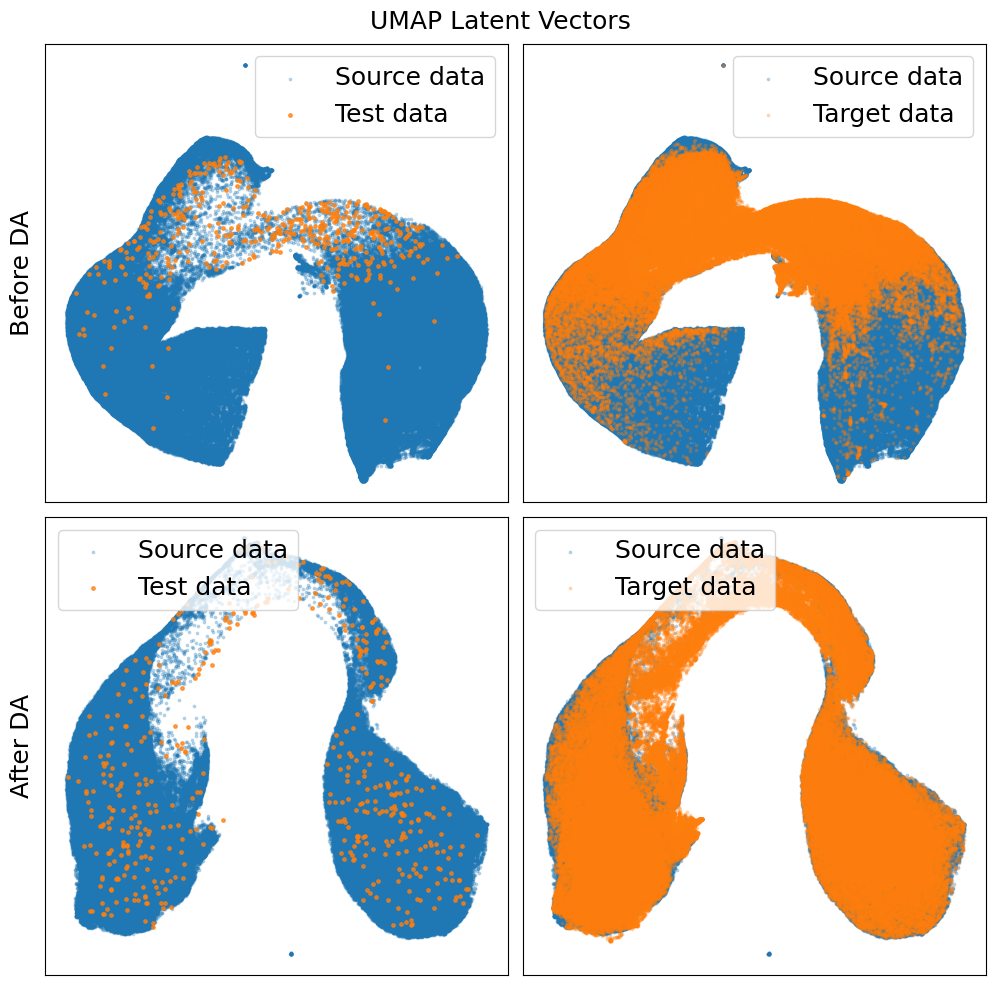

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

axes[0][0].scatter(synt_umap[:, 0], synt_umap[:, 1], s=3, alpha=0.25, label="Source data")
axes[0][0].scatter(test_umap[:, 0], test_umap[:, 1], s=6, alpha=0.75, label="Test data")
axes[0][0].legend(fontsize=18)
axes[0][0].set_xticks([])
axes[0][0].set_yticks([])
axes[0][0].text(
    -0.05, 0.5,
    "Before DA",
    transform=axes[0][0].transAxes,
    rotation=90,
    va="center",
    ha="center",
    fontsize=18,
)

axes[0][1].scatter(synt_umap[:, 0], synt_umap[:, 1], s=3, alpha=0.25, label="Source data")
axes[0][1].scatter(real_umap[:, 0], real_umap[:, 1], s=3, alpha=0.25, label="Target data")
axes[0][1].legend(fontsize=18)
axes[0][1].set_xticks([])
axes[0][1].set_yticks([])

axes[1][0].scatter(synt_umap_da[:, 0], synt_umap_da[:, 1], s=3, alpha=0.25, label="Source data")
axes[1][0].scatter(test_umap_da[:, 0], test_umap_da[:, 1], s=6, alpha=0.75, label="Test data")
axes[1][0].legend(fontsize=18)
axes[1][0].set_xticks([])
axes[1][0].set_yticks([])
axes[1][0].text(
    -0.05, 0.5,
    "After DA",
    transform=axes[1][0].transAxes,
    rotation=90,
    va="center",
    ha="center",
    fontsize=18,
)

axes[1][1].scatter(synt_umap_da[:, 0], synt_umap_da[:, 1], s=3, alpha=0.25, label="Source data")
axes[1][1].scatter(real_umap_da[:, 0], real_umap_da[:, 1], s=3, alpha=0.25, label="Target data")
axes[1][1].legend(fontsize=18)
axes[1][1].set_xticks([])
axes[1][1].set_yticks([])

plt.suptitle("UMAP Latent Vectors", fontsize=18)
fig.tight_layout()
plt.show()

In [19]:
# # synt_labels = np.asarray(load_latents(synt_labels_path))
# synt_labels_da = np.asarray(load_latents(synt_labels_path_da))

# # test_labels = np.asarray(load_latents(test_labels_path))
# test_labels_da = np.asarray(load_latents(test_lables_path_da))

# all_labels = np.concatenate([synt_labels_da, test_labels_da]) # synt_labels, test_labels,
# unique_labels = sorted(np.unique(all_labels))

# markers = {
#     unique_labels[0]: "o",
#     unique_labels[1]: "^",
# }

# label_names = {
#     unique_labels[0]: "Compact",
#     unique_labels[1]: "Extended",
# }


# def plot_labelled_points(
#     ax,
#     embedding,
#     labels,
#     domain_name,
#     color,
#     size,
#     alpha,
#     edge=False,
# ):
#     labels = np.asarray(labels)

#     for label in unique_labels:
#         mask = labels == label

#         ax.scatter(
#             embedding[mask, 0],
#             embedding[mask, 1],
#             s=size,
#             alpha=alpha,
#             marker=markers[label],
#             c=color,
#             edgecolors="black" if edge else "none",
#             linewidths=0.4 if edge else 0,
#             label=f"{domain_name}: {label_names[label]}",
#         )

/home/zagorulia/ml/train/embeddings_for_umap/test_labels.npy <class 'numpy.ndarray'> (472,)
../scripts/model.ptcnn_DA_20260401-230242/y_true/y_true_CNN_test_conf_mat_best_model_val_acc.npy <class 'numpy.ndarray'> (472,)


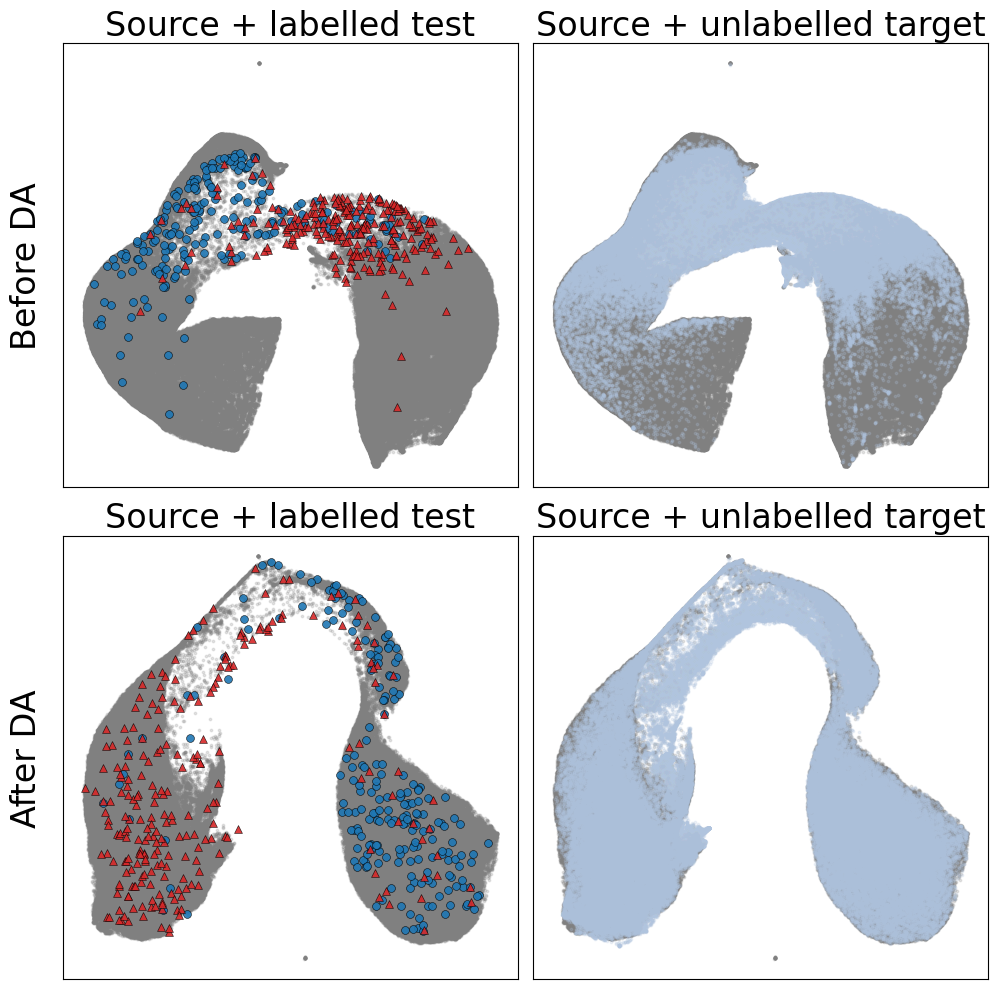

In [27]:
test_labels = np.asarray(load_latents(test_lables_path))
test_labels_da = np.asarray(load_latents(test_lables_path_da))

unique_labels = sorted(np.unique(test_labels_da))

markers = {
    unique_labels[0]: "o",
    unique_labels[1]: "^",
}

colors = {
    unique_labels[0]: "tab:blue",
    unique_labels[1]: "tab:red",
}

label_names = {
    unique_labels[0]: "Compact",
    unique_labels[1]: "Extended",
}

fontsize = 24


def plot_test_points(ax, embedding, labels, prefix="Test"):
    labels = np.asarray(labels)

    for label in unique_labels:
        mask = labels == label

        ax.scatter(
            embedding[mask, 0],
            embedding[mask, 1],
            s=32,
            alpha=0.9,
            marker=markers[label],
            c=colors[label],
            edgecolors="black",
            linewidths=0.4,
            label=f"{prefix}: {label_names[label]}",
        )


fig, axes = plt.subplots(2, 2, figsize=(10, 10))

# BEFORE DA: source + labelled test
axes[0][0].scatter(
    synt_umap[:, 0],
    synt_umap[:, 1],
    s=3,
    alpha=0.2,
    c="gray",
    label="Source data",
)

plot_test_points(
    axes[0][0],
    test_umap,
    test_labels,
)

axes[0][0].set_title("Source + labelled test", fontsize=fontsize)


# BEFORE DA: source + target
axes[0][1].scatter(
    synt_umap[:, 0],
    synt_umap[:, 1],
    s=3,
    alpha=0.2,
    c="gray",
    label="Source data",
)

axes[0][1].scatter(
    real_umap[:, 0],
    real_umap[:, 1],
    s=3,
    alpha=0.2,
    c="lightsteelblue",
    label="Target data",
)

axes[0][1].set_title("Source + unlabelled target", fontsize=fontsize)


# AFTER DA: source + labelled test
axes[1][0].scatter(
    synt_umap_da[:, 0],
    synt_umap_da[:, 1],
    s=3,
    alpha=0.2,
    c="gray",
    label="Source data",
)

plot_test_points(
    axes[1][0],
    test_umap_da,
    test_labels_da,
)

axes[1][0].set_title("Source + labelled test", fontsize=fontsize)


# AFTER DA: source + target
axes[1][1].scatter(
    synt_umap_da[:, 0],
    synt_umap_da[:, 1],
    s=3,
    alpha=0.2,
    c="gray",
    label="Source data",
)

axes[1][1].scatter(
    real_umap_da[:, 0],
    real_umap_da[:, 1],
    s=3,
    alpha=0.2,
    c="lightsteelblue",
    label="Target data",
)

axes[1][1].set_title("Source + unlabelled target", fontsize=fontsize)


for ax in axes.ravel():
    ax.set_xticks([])
    ax.set_yticks([])
    # ax.legend(fontsize=18, frameon=False)

axes[0][0].text(
    -0.08, 0.5, "Before DA",
    transform=axes[0][0].transAxes,
    rotation=90,
    va="center",
    ha="center",
    fontsize=fontsize,
)

axes[1][0].text(
    -0.08, 0.5, "After DA",
    transform=axes[1][0].transAxes,
    rotation=90,
    va="center",
    ha="center",
    fontsize=fontsize,
)

# plt.suptitle("UMAP latent representations", fontsize=20)
fig.tight_layout()
plt.show()

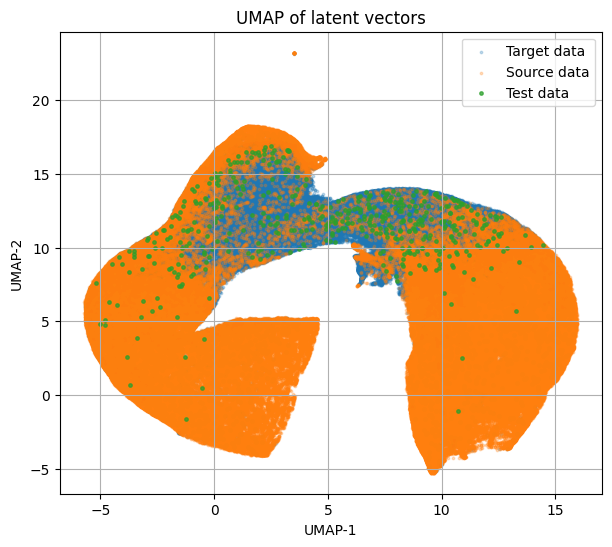

In [21]:
fig, ax = plt.subplots(figsize=(7, 6))

# plot target first as background
ax.scatter(real_umap[:, 0], real_umap[:, 1], s=3, alpha=0.25, label="Target data")
ax.scatter(synt_umap[:, 0], synt_umap[:, 1], s=3, alpha=0.25, label="Source data")
ax.scatter(test_umap[:, 0], test_umap[:, 1], s=6, alpha=0.75, label="Test data")

ax.set_title("UMAP of latent vectors")
ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")
ax.legend()
ax.grid()
plt.show()

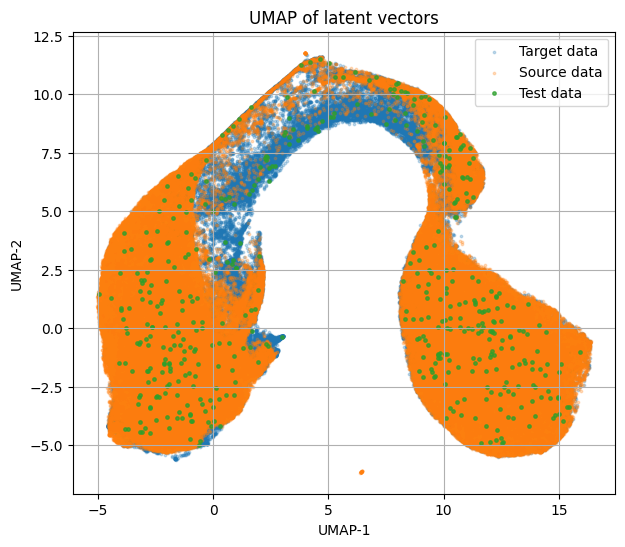

In [22]:
fig, ax = plt.subplots(figsize=(7, 6))

# plot target first as background
ax.scatter(real_umap_da[:, 0], real_umap_da[:, 1], s=3, alpha=0.25, label="Target data")
ax.scatter(synt_umap_da[:, 0], synt_umap_da[:, 1], s=3, alpha=0.25, label="Source data")
ax.scatter(test_umap_da[:, 0], test_umap_da[:, 1], s=6, alpha=0.75, label="Test data")

ax.set_title("UMAP of latent vectors")
ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")
ax.legend()
ax.grid()
plt.show()

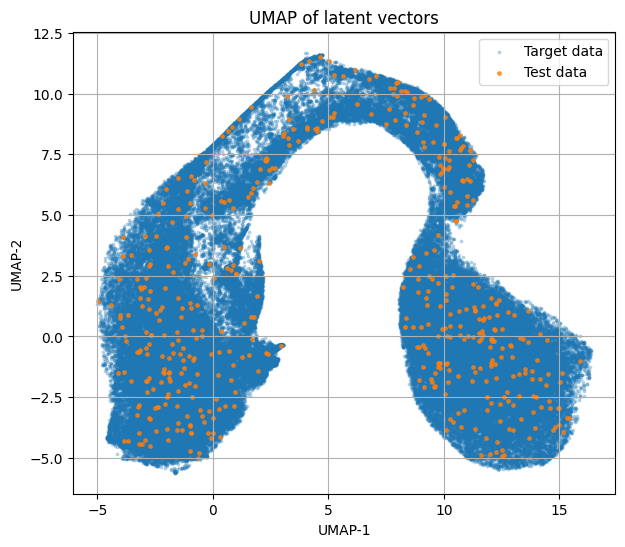

In [23]:
fig, ax = plt.subplots(figsize=(7, 6))

# plot target first as background
ax.scatter(real_umap_da[:, 0], real_umap_da[:, 1], s=3, alpha=0.25, label="Target data")
# ax.scatter(synt_umap_da[:, 0], synt_umap_da[:, 1], s=3, alpha=0.25, label="Source data")
ax.scatter(test_umap_da[:, 0], test_umap_da[:, 1], s=6, alpha=0.75, label="Test data")

ax.set_title("UMAP of latent vectors")
ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")
ax.legend()
ax.grid()
plt.show()